In [25]:
import os
import numpy as np
from keras_facenet import FaceNet
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def preprocess_image(image_path, target_size=(160, 160)):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=target_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array /= 255.0 
    return img_array


In [26]:
import splitfolders

source_dir = "../data/faces_retinaface/train_faces" 
output_dir = "../data/faces_retinaface/training_validation_split" 

splitfolders.ratio(
    source_dir, 
    output=output_dir, 
    seed=42, 
    ratio=(0.8, 0.2),  
    group_prefix=None 
)


Copying files: 0 files [00:00, ? files/s]

Copying files: 1236 files [00:00, 1842.21 files/s]


In [27]:
facenet = FaceNet()
base_model = facenet.model


In [28]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "../data/faces_retinaface/training_validation_split/train"
val_dir = "../data/faces_retinaface/training_validation_split/val"

batch_size = 32
target_size = (160, 160)  
num_classes = len(os.listdir(train_dir)) 

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,  
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,  
    brightness_range=[0.8,1.2], 
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1.0 / 255  
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="categorical" 
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="categorical" 
)

label_map = train_generator.class_indices  
label_map_reverse = {v: k for k, v in label_map.items()}

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output_layer = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output_layer)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Found 983 images belonging to 14 classes.
Found 253 images belonging to 14 classes.


In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.1, patience=3, min_lr=1e-6)
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=callbacks,  
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator),
)


Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 24s 457ms/step - accuracy: 0.3014 - loss: 2.5139 - val_accuracy: 0.6957 - val_loss: 1.9889 - learning_rate: 0.0010
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 376ms/step - accuracy: 0.6365 - loss: 1.9053 - val_accuracy: 0.7984 - val_loss: 1.3107 - learning_rate: 0.0010
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 398ms/step - accuracy: 0.7491 - loss: 1.3383 - val_accuracy: 0.8340 - val_loss: 0.9095 - learning_rate: 0.0010
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 394ms/step - accuracy: 0.7739 - loss: 1.0734 - val_accuracy: 0.8538 - val_loss: 0.7295 - learning_rate: 0.0010
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 394ms/step - accuracy: 0.7999 - loss: 0.8834 - val_accuracy: 0.8577 - val_loss: 0.6418 - learning_rate: 0.0010
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 403ms/step - accuracy: 0.8103 - loss: 0.7781 - val_accuracy: 0.8577 - val_loss: 0.5971 - learning_rate: 0.0010
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 391ms/step - accuracy: 0.7960 - loss: 0.

In [30]:
# model.save("../models/facenet_flow_from_directory2.h5")
# model.save("../models/facenet_flow_from_directory2.keras")

In [31]:
model_json = model.to_json()
with open("../models/facenet_flow_from_directory4.json", "w") as json_file:
    json_file.write(model_json)

model.save_weights("../models/facenet_flow_from_directory4.weights.h5")


In [32]:
facenet = FaceNet()
base_model = facenet.model

x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output_layer = Dense(num_classes, activation='softmax')(x)

loaded_model = Model(inputs=base_model.input, outputs=output_layer)


loaded_model.load_weights("../models/facenet_flow_from_directory4.weights.h5")

In [33]:
def load_test_data(test_folder, target_size=(160, 160)):
    test_images = []
    filenames = []
    for filename in sorted(os.listdir(test_folder)):
        img_path = os.path.join(test_folder, filename)
        img = preprocess_image(img_path, target_size)
        test_images.append(img)
        filenames.append(filename)
    return np.array(test_images), filenames

test_folder = "../data/faces_retinaface_2/test_faces"
test_images, test_filenames = load_test_data(test_folder)

predictions = loaded_model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

label_map_reverse = {v: k for k, v in train_generator.class_indices.items()}
predicted_names = [label_map_reverse[int(label)] for label in predicted_labels]

print(f"Predicted Names: {predicted_names}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 588ms/step
Predicted Names: ['senne', 'senne', 'youssef', 'konrad', 'seppe', 'alper', 'daiane', 'senne', 'raul', 'raul', 'lasse', 'bart', 'konrad', 'seppe', 'florian', 'alper', 'daiane', 'alper', 'youssef', 'senne', 'akif', 'florian', 'akif', 'konrad', 'bart', 'alper', 'akif', 'senne', 'youssef', 'michiel', 'raul', 'alper', 'seppe', 'daiane', 'senne', 'michiel', 'matthias', 'lasse', 'matthias', 'florian', 'lasse', 'bart', 'akif', 'senne', 'nelli', 'lasse', 'youssef', 'matthias', 'alper', 'lasse', 'bart', 'alper', 'akif', 'seppe', 'raul', 'senne', 'nelli', 'senne', 'daiane', 'senne', 'seppe', 'daiane', 'michiel', 'raul', 'youssef', 'seppe', 'nelli', 'seppe', 'matthias', 'daiane', 'matthias', 'alper', 'alper', 'bart', 'florian', 'seppe', 'alper', 'alper', 'lasse', 'matthias', 'bart', 'akif', 'michiel', 'raul', 'bart', 'lasse', 'lasse', 'raul', 'alper', 'florian', 'matthias', 'bart', 'lasse', 'lasse', 'senne', 'michiel', 'youssef', 'lasse', 'matthias', 'bart', 

In [36]:
import os
import pandas as pd

def create_submission(filenames, predictions, output_path, image_folder):
    base_filenames = [filename.split('_face')[0] for filename in filenames]

    grouped_results = {}
    for base, prediction in zip(base_filenames, predictions):
        if base not in grouped_results:
            grouped_results[base] = []
        grouped_results[base].append(prediction)

    all_filenames = sorted(
        [os.path.splitext(filename)[0] for filename in os.listdir(image_folder) if filename.endswith('.jpg')]
    )

    submission_data = []
    for filename in all_filenames:
        if filename in grouped_results:
            label_name = ";".join(grouped_results[filename])
        else:
            label_name = "nothing"  
        submission_data.append({"image": filename, "label_name": label_name})

    submission_df = pd.DataFrame(submission_data)
    submission_df.to_csv(output_path, index=False)
    print(f"Submission saved to {output_path}")

image_folder = "../data/images/test_images/cleaned_images"
output_path = "../submission.csv"
create_submission(test_filenames, predicted_names, output_path, image_folder)


Submission saved to ../submission.csv


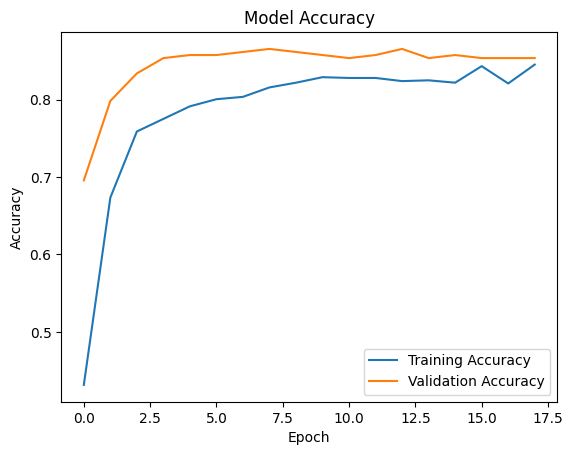

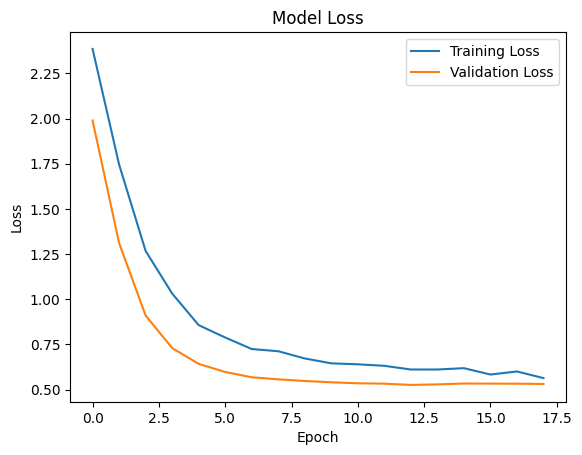

In [35]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
